# 1 · Evaluación, baseline y cómo reproducirlo

Acá explicamos **cómo medimos, cómo se entrena un modelo, y cómo reproducir todo**.
Después fijamos el baseline (Isolation Forest) que hay que superar.

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

## 1 · Cómo se entrena y evalúa un modelo (y cómo correrlo vos)
Todo modelo cumple la interfaz `AnomalyDetector`: `fit(X_train)` (solo normales) +
`score_samples(X)`. El helper `explib.run_experiment` **carga** el run guardado o, con
`force_train=True`, lo **entrena de verdad** con el pipeline real y lo guarda en `runs/`.

Veamos la configuración del baseline (un YAML de `configs/`):

In [2]:
explib.show_yaml("configs/iforest/iforest_v2_mf03_n200.yaml")

model: iforest
name: iforest_v2_mf03_n200
cultivo: ambos

# Tuning: max_features bajo (0.3 ≈ 16 de 54 features por árbol) suele mejorar
# la sensibilidad a anomalías locales en datasets con muchas features.
n_estimators: 200
max_samples: auto
max_features: 0.3
contamination: auto
random_state: 42

n_seeds: 10
threshold_mode: contamination
eval_contamination: 0.10



In [3]:
explib.describe_architecture("configs/iforest/iforest_v2_mf03_n200.yaml")

Modelo: Isolation Forest
  n_estimators=200 max_features=0.3 max_samples=auto

  Optimización: lr=— epochs=— patience=— batch=— n_seeds=10


**Entrenarlo / cargarlo** (poné `force_train=True` para re-entrenar — tarda unos
segundos el IForest; los VAE, varios minutos):

In [4]:
res = explib.run_experiment("configs/iforest/iforest_v2_mf03_n200.yaml", "soja",
                            force_train=False)   # ← cambiá a True para entrenarlo vos
print("run:", res.run_id)

run: iforest_v2_mf03_n200__soja__20260630_115941


## 2 · Métricas: por qué PR-AUC (y no F1), y por qué reportamos desvío
- **PR-AUC** (principal) y **ROC-AUC**: libres de umbral.
- **F1 es engañoso acá**: el umbral se calibra en val (pocas anomalías) y en test la tasa
  base salta a ~30% → casi todos dan F1 ≈ tasa base. No lo usamos para decidir.
- **Multi-seed**: reportamos **media ± desvío** porque los modelos profundos varían entre
  semillas.

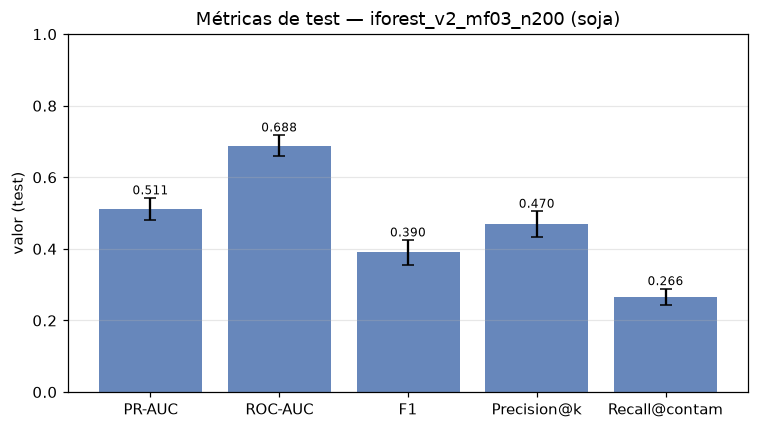

In [5]:
explib.plot_all_metrics("iforest_v2_mf03_n200", "soja"); plt.show()

### Matriz de confusión y el punto de operación
Las métricas de arriba (PR-AUC) son **libres de umbral** — miden el *ranking*. La matriz de
confusión necesita un **corte**, y ahí hay una sutileza importante:

> ⚠️ **El umbral calibrado en validación NO transfiere a test.** Se calibra como el percentil
> 90 de los scores de *val*, pero los scores se corren mucho hacia arriba entre val (2018–20)
> y test (2021–24) —el clima se aleja del período de entrenamiento— así que ese corte termina
> marcando **~70% del test** como anómalo. No es que el modelo crea que el 70% son anómalas:
> es el *distribution shift* lavando un corte absoluto.

Por eso re-umbralizamos sobre los **scores del propio test** (sin usar etiquetas para el
corte) en **dos puntos de operación**: **top-10%** (presupuesto de alertas acotado) y
**top-tasa real** (~27%, la fracción que realmente es anómala en test). Filas = real,
columnas = predicho.

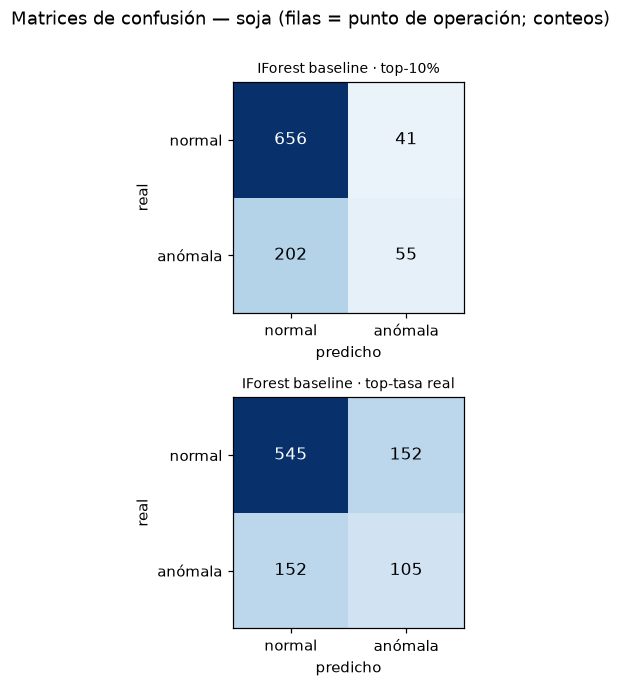

In [6]:
explib.plot_confusion_grid([("iforest_v2_mf03_n200","IForest baseline")], "soja"); plt.show()

In [7]:
explib.show(explib.confusion_report("iforest_v2_mf03_n200", "soja"))

,top-10%,top-tasa real
TP/FP/FN/TN,55/41/202/656,105/152/152/545
Precision,0.573,0.409
Recall,0.214,0.409
Especificidad,0.941,0.782
F1,0.312,0.409
Balanced acc,0.578,0.595


Leído así, el punto de operación se entiende: al **top-10%** la precisión es alta
(casi todo lo que marca es anomalía real) pero el recall bajo (con 10% de presupuesto no se
puede cubrir el 27% que hay); al **top-tasa real** precision y recall se igualan. Este es el
patrón con el que comparar todos los modelos.

## 3 · ⚠️ Selección en validación, no en test (nota metodológica)
**Lo correcto** es *elegir* el mejor modelo mirando **validación**, y usar **test una sola
vez** para el número final del modelo ya elegido. Comparar muchos modelos en test y quedarse
con el ganador sesga la métrica (data snooping).

**Limitación de este proyecto:** nuestro val es chico (5–9 anomalías) → ruidoso. Por eso a
lo largo de los notebooks mostramos test (más estable) para *ilustrar* las comparaciones,
pero la **decisión final** debería apoyarse en val. Acá los dos, lado a lado:

In [8]:
modelos = [("iforest_v2_mf03_n200","IForest"), ("vae_seedens_v1","VAE seed-ens"),
           ("vae_v4_reconprob_lat16","VAE single")]
print("— VALIDACIÓN —"); display(explib.show(explib.compare_table(modelos, "soja", split="val")))
print("— TEST —");       display(explib.show(explib.compare_table(modelos, "soja", split="test")))

— VALIDACIÓN —


,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,IForest,0.046±0.002,0.355±0.031,0.010±0.009,0.023,0.023
1,VAE seed-ens,0.045±0.001,0.351±0.010,0.017±0.000,0.023,0.023
2,VAE single,0.049±0.004,0.382±0.043,0.033±0.016,0.023,0.045


— TEST —


,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,IForest,0.511±0.031,0.688±0.030,0.390±0.034,0.470±0.035,0.266±0.023
1,VAE seed-ens,0.592±0.010,0.738±0.005,0.432±0.003,0.558±0.013,0.297±0.002
2,VAE single,0.559±0.035,0.719±0.027,0.486±0.026,0.518±0.035,0.279±0.018


El ranking en val y en test **coincide** (el VAE seed-ensemble gana en ambos), así
que la conclusión se sostiene; pero dejamos explícita la limitación.

## 4 · El baseline a superar: Isolation Forest = **PR-AUC 0.51 (soja)**
Es el listón de toda la historia. En los próximos notebooks vamos modelo por modelo.